In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# PyTorch 2.3.1 + CUDA 12.1 — has pre-built mamba_ssm wheels
!pip install torch==2.3.1 torchvision==0.18.1 --index-url https://download.pytorch.org/whl/cu121 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.9/780.9 MB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 95.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 78.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 53.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 96.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 809.5 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 13.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 7.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 6.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.2/176.2 MB 6.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
!pip install torchvision==0.18.1 -q
!pip install transformers==4.40.0 -q
!pip install tokenizers==0.19.1 -q
!pip install torchmetrics==1.4.0 -q
!pip install medpy -q
!pip install timm einops albumentations -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 55.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 62.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.5.1 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 868.8/868.8 kB 23.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.3/156.3 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 21.3 MB/s eta 0:00:00


In [4]:
import torch
print(torch.version.cuda)
print(torch.__version__)

12.1
2.3.1+cu121


In [5]:
!pip install causal-conv1d==1.4.0 -q
!pip install mamba-ssm==2.2.2 -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 5.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [6]:
import torch
from mamba_ssm.ops.selective_scan_interface import selective_scan_fn
print("mamba_ssm loaded successfully!")
print(torch.__version__)   # should be 2.3.1+cu121

mamba_ssm loaded successfully!
2.3.1+cu121


In [7]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

import albumentations as A
from albumentations.pytorch import ToTensorV2

import torchmetrics
from torchmetrics import JaccardIndex, F1Score, Accuracy, Precision, Recall, Specificity
from medpy.metric import binary

# For reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
!sed -i 's/from .vmamba import/from vmamba import/' /content/vmunet.py

In [ ]:
!head -3 /content/vmunet.py  # should show: from vmamba import VSSM

from vmamba import VSSM
import torch
from torch import nn


In [8]:
drive_source='/content/lib'

In [12]:
from google.colab import drive
import shutil
import os
import shutil, os
drive_source = '/content/lib'
for file in ['vmamba.py', 'rmsnet.py']:
    src = os.path.join(drive_source, file)
    if os.path.exists(src):
        shutil.copy(src, '.')
        print(f"✅ {file} loaded")
    else:
        print(f"❌ Missing: {file}")

# Now you can import
from rmsnet import RMSNet
print("VMUNet imported successfully!")

✅ vmamba.py loaded
✅ rmsnet.py loaded


ImportError: attempted relative import with no known parent package

In [13]:
for file in ['vmamba.py', 'rmsnet.py']:
    src = os.path.join(drive_source, file)
    if os.path.exists(src):
        shutil.copy(src, '.')
        print(f"✅ {file} loaded")
    else:
        print(f"❌ Missing: {file}")

# Fix the import in vmunet.py
with open('rmsnet.py', 'r') as f:
    content = f.read()

# Replace relative import with absolute import
content = content.replace('from .vmamba import VSSM', 'from vmamba import VSSM')

with open('rmsnet.py', 'w') as f:
    f.write(content)

print("Fixed vmunet.py: changed relative import to absolute import")

# Now import
from rmsnet import RMSNet
print("VMUNet imported successfully!")

✅ vmamba.py loaded
✅ rmsnet.py loaded
Fixed vmunet.py: changed relative import to absolute import
VMUNet imported successfully!


In [14]:
from rmsnet import RMSNet
print("VMUNet imported successfully!")

VMUNet imported successfully!


In [15]:
data_dir = "/content/drive/MyDrive/Kvasir-SEG"
image_dir = os.path.join(data_dir, "images")
mask_dir = os.path.join(data_dir, "masks")

IMG_HEIGHT = 256
IMG_WIDTH = 256
batch_size = 8          # adjust based on GPU memory
learning_rate = 1e-3
num_epochs = 100
patience = 40

os.makedirs("models", exist_ok=True)
os.makedirs("logs", exist_ok=True)
os.makedirs("results", exist_ok=True)

# Get all image and mask files
image_files = sorted(os.listdir(image_dir))
mask_files = sorted(os.listdir(mask_dir))
image_paths = [os.path.join(image_dir, f) for f in image_files]
mask_paths = [os.path.join(mask_dir, f) for f in mask_files]

# Split
from sklearn.model_selection import train_test_split
temp = list(zip(image_paths, mask_paths))
train_val, test = train_test_split(temp, test_size=0.15, random_state=42)
train, val = train_test_split(train_val, test_size=0.15/0.85, random_state=42)

print(f"Train: {len(train)}, Val: {len(val)}, Test: {len(test)}")

Train: 700, Val: 150, Test: 150


In [16]:
class KvasirDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = cv2.imread(self.image_paths[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype(np.uint8)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
        else:
            image = torch.from_numpy(image).permute(2,0,1).float() / 255.0
            mask = torch.from_numpy(mask).long()
        return image, mask

# Transforms
train_transform = A.Compose([
    A.Resize(IMG_HEIGHT, IMG_WIDTH),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMG_HEIGHT, IMG_WIDTH),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

train_dataset = KvasirDataset(*zip(*train), transform=train_transform)
val_dataset = KvasirDataset(*zip(*val), transform=val_transform)
test_dataset = KvasirDataset(*zip(*test), transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

In [17]:
class DiceBCELoss(nn.Module):
    def __init__(self, dice_weight=0.5, bce_weight=0.5):
        super().__init__()
        self.dice_weight = dice_weight
        self.bce_weight = bce_weight
        self.bce = nn.BCELoss()   # now expects probabilities

    def forward(self, inputs, targets):
        # inputs: (N,1,H,W) probabilities in [0,1]
        # targets: (N,H,W) long (0/1)
        inputs = inputs.squeeze(1)  # (N,H,W)
        targets = targets.float()

        smooth = 1e-5
        intersection = (inputs * targets).sum()
        dice_loss = 1 - (2. * intersection + smooth) / (inputs.sum() + targets.sum() + smooth)

        bce_loss = self.bce(inputs, targets)

        return self.dice_weight * dice_loss + self.bce_weight * bce_loss

criterion = DiceBCELoss().to(device)

In [18]:
from rmsnet import RMSNet

model = RMSNet(
    input_channels=3,
    num_classes=1,
    depths=[2, 2, 9, 2],
    depths_decoder=[2, 9, 2, 2],
    drop_path_rate=0.2,
    load_ckpt_path=None
).to(device)

# Optional: load pre-trained encoder weights (comment out if not needed)
# model.load_from()

optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=20)

print(f"Total parameters: {sum(p.numel() for p in model.parameters())/1e6:.2f}M")

Total parameters: 47.86M


In [19]:
jaccard = JaccardIndex(task='binary').to(device)
dice = F1Score(task='binary').to(device)
accuracy = Accuracy(task='binary').to(device)
precision = Precision(task='binary').to(device)
recall = Recall(task='binary').to(device)
specificity = Specificity(task='binary').to(device)

def compute_hausdorff(pred_mask, true_mask, spacing=(1,1)):
    pred_binary = pred_mask.astype(np.uint8)
    true_binary = true_mask.astype(np.uint8)
    if np.sum(pred_binary) == 0 or np.sum(true_binary) == 0:
        return np.nan, np.nan
    hd = binary.hd(pred_binary, true_binary, voxelspacing=spacing)
    hd95 = binary.hd95(pred_binary, true_binary, voxelspacing=spacing)
    return hd, hd95

In [20]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total_pixels = 0

    for images, masks in tqdm(dataloader, desc='Training'):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)          # (N,1,H,W) probabilities
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = (outputs > 0.5).squeeze(1).long()
        correct += (preds == masks).sum().item()
        total_pixels += masks.numel()

    avg_loss = total_loss / len(dataloader)
    avg_acc = correct / total_pixels
    return avg_loss, avg_acc

def validate_one_epoch(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    jaccard.reset()
    dice.reset()
    accuracy.reset()
    precision.reset()
    recall.reset()
    specificity.reset()
    hd_list, hd95_list = [], []

    with torch.no_grad():
        for images, masks in tqdm(dataloader, desc='Validation'):
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)
            total_loss += loss.item()

            preds = (outputs > 0.5).squeeze(1).long()

            jaccard.update(preds, masks)
            dice.update(preds, masks)
            accuracy.update(preds, masks)
            precision.update(preds, masks)
            recall.update(preds, masks)
            specificity.update(preds, masks)

            for i in range(images.size(0)):
                pred_np = preds[i].cpu().numpy()
                mask_np = masks[i].cpu().numpy()
                hd, hd95 = compute_hausdorff(pred_np, mask_np)
                hd_list.append(hd)
                hd95_list.append(hd95)

    avg_loss = total_loss / len(dataloader)
    metrics = {
        'loss': avg_loss,
        'val_accuracy': accuracy.compute().cpu().item(),
        'jaccard': jaccard.compute().cpu().item(),
        'dice': dice.compute().cpu().item(),
        'precision': precision.compute().cpu().item(),
        'recall': recall.compute().cpu().item(),
        'specificity': specificity.compute().cpu().item(),
        'hd_mean': np.nanmean(hd_list),
        'hd95_mean': np.nanmean(hd95_list)
    }
    return metrics

In [21]:
log_file = "logs/training_log.csv"
csv_columns = ['epoch', 'train_loss', 'train_accuracy', 'val_loss', 'val_accuracy',
               'jaccard', 'dice', 'precision', 'recall', 'specificity',
               'hd_mean', 'hd95_mean']

if not os.path.exists(log_file):
    pd.DataFrame(columns=csv_columns).to_csv(log_file, index=False)

best_val_loss = float('inf')
patience_counter = 0
history = defaultdict(list)

for epoch in range(1, num_epochs+1):
    print(f"\nEpoch {epoch}/{num_epochs}")

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    scheduler.step(val_metrics['loss'])

    history['epoch'].append(epoch)
    history['train_loss'].append(train_loss)
    history['train_accuracy'].append(train_acc)
    history['val_loss'].append(val_metrics['loss'])          # ← key fix
    history['val_accuracy'].append(val_metrics['val_accuracy'])
    history['jaccard'].append(val_metrics['jaccard'])
    history['dice'].append(val_metrics['dice'])
    history['precision'].append(val_metrics['precision'])
    history['recall'].append(val_metrics['recall'])
    history['specificity'].append(val_metrics['specificity'])
    history['hd_mean'].append(val_metrics['hd_mean'])
    history['hd95_mean'].append(val_metrics['hd95_mean'])

    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_metrics['loss']:.4f}")
    print(f"Train Acc:  {train_acc:.4f} | Val Acc:  {val_metrics['val_accuracy']:.4f}")
    print(f"Jaccard: {val_metrics['jaccard']:.4f} | Dice: {val_metrics['dice']:.4f}")
    print(f"HD: {val_metrics['hd_mean']:.2f} | HD95: {val_metrics['hd95_mean']:.2f}")

    row = {col: history[col][-1] for col in csv_columns}
    pd.DataFrame([row]).to_csv(log_file, mode='a', header=False, index=False)

    if val_metrics['loss'] < best_val_loss:
        best_val_loss = val_metrics['loss']
        torch.save(model.state_dict(), 'models/best_vmunet.pth')
        print("Best model saved!")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

torch.save(model.state_dict(), 'models/final_vmunet.pth')


Epoch 1/100


Validation: 100%|██████████| 19/19 [00:28<00:00,  1.48s/it]


Train Loss: 0.5293 | Val Loss: 0.5127
Train Acc:  0.8067 | Val Acc:  0.7972
Jaccard: 0.3203 | Dice: 0.4852
HD: 94.32 | HD95: 78.92
Best model saved!

Epoch 2/100


Validation: 100%|██████████| 19/19 [00:08<00:00,  2.16it/s]


Train Loss: 0.4852 | Val Loss: 0.4859
Train Acc:  0.8362 | Val Acc:  0.8177
Jaccard: 0.3308 | Dice: 0.4971
HD: 92.28 | HD95: 75.71
Best model saved!

Epoch 3/100


...

Train Loss: 0.4974 | Val Loss: 0.5058
Train Acc:  0.8295 | Val Acc:  0.8276
Jaccard: 0.2718 | Dice: 0.4274
HD: 89.63 | HD95: 74.30

Epoch 4/100


Validation: 100%|██████████| 19/19 [00:09<00:00,  2.01it/s]


Train Loss: 0.4810 | Val Loss: 0.5179
Train Acc:  0.8386 | Val Acc:  0.7965
Jaccard: 0.3081 | Dice: 0.4710
HD: 99.65 | HD95: 84.91

Epoch 5/100


Training:  31%|███       | 27/88 [00:26<00:59,  1.02it/s]


KeyboardInterrupt: 

In [ ]:
def plot_individual_curves(history):
    os.makedirs("results", exist_ok=True)
    epochs = history['epoch']

    # Loss
    plt.figure(figsize=(8,6))
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'], label='Val Loss')  # Changed from 'loss' to 'val_loss'
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss Curves')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('results/loss_curve.png', dpi=150)
    plt.show()
    print("Saved: results/loss_curve.png")

    # Accuracy
    plt.figure(figsize=(8,6))
    plt.plot(epochs, history['train_accuracy'], label='Train Accuracy')
    plt.plot(epochs, history['val_accuracy'], label='Val Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy Curves')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('results/accuracy_curve.png', dpi=150)
    plt.show()
    print("Saved: results/accuracy_curve.png")

    # Jaccard & Dice
    plt.figure(figsize=(8,6))
    plt.plot(epochs, history['jaccard'], label='Jaccard (IoU)')
    plt.plot(epochs, history['dice'], label='Dice')
    plt.xlabel('Epoch')
    plt.ylabel('Score')
    plt.title('Jaccard and Dice')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('results/jaccard_dice_curve.png', dpi=150)
    plt.show()
    print("Saved: results/jaccard_dice_curve.png")

    # Precision/Recall/Specificity
    plt.figure(figsize=(8,6))
    plt.plot(epochs, history['precision'], label='Precision')
    plt.plot(epochs, history['recall'], label='Recall')
    plt.plot(epochs, history['specificity'], label='Specificity')
    plt.xlabel('Epoch')
    plt.ylabel('Score')
    plt.title('Precision, Recall, Specificity')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('results/precision_recall_specificity.png', dpi=150)
    plt.show()
    print("Saved: results/precision_recall_specificity.png")

    # Hausdorff
    plt.figure(figsize=(8,6))
    plt.plot(epochs, history['hd_mean'], label='HD')
    plt.plot(epochs, history['hd95_mean'], label='HD95')
    plt.xlabel('Epoch')
    plt.ylabel('Distance')
    plt.title('Hausdorff Distance')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('results/hausdorff_curve.png', dpi=150)
    plt.show()
    print("Saved: results/hausdorff_curve.png")

In [ ]:
# Load best model
model.load_state_dict(torch.load('/content/models/best_vmunet.pth'))
model.eval()

# Reset metrics
jaccard.reset()
dice.reset()
accuracy.reset()
precision.reset()
recall.reset()
specificity.reset()
hd_list = []
hd95_list = []
test_loss_total = 0

with torch.no_grad():
    for images, masks in tqdm(test_loader, desc='Testing'):
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)
        loss = criterion(outputs, masks)
        test_loss_total += loss.item()

        preds = (torch.sigmoid(outputs) > 0.5).squeeze(1).long()

        jaccard.update(preds, masks)
        dice.update(preds, masks)
        accuracy.update(preds, masks)
        precision.update(preds, masks)
        recall.update(preds, masks)
        specificity.update(preds, masks)

        for i in range(images.size(0)):
            pred_np = preds[i].cpu().numpy()
            mask_np = masks[i].cpu().numpy()
            hd, hd95 = compute_hausdorff(pred_np, mask_np)
            hd_list.append(hd)
            hd95_list.append(hd95)

avg_test_loss = test_loss_total / len(test_loader)

# Final metrics
jaccard_score = jaccard.compute().cpu().item()
dice_score = dice.compute().cpu().item()
acc_score = accuracy.compute().cpu().item()
prec_score = precision.compute().cpu().item()
rec_score = recall.compute().cpu().item()
spec_score = specificity.compute().cpu().item()
hd_mean = np.nanmean(hd_list)
hd95_mean = np.nanmean(hd95_list)

print("\n===== Test Set Results =====")
print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Accuracy: {acc_score:.4f}")
print(f"Jaccard: {jaccard_score:.4f}")
print(f"Dice: {dice_score:.4f}")
print(f"Precision: {prec_score:.4f}")
print(f"Recall: {rec_score:.4f}")
print(f"Specificity: {spec_score:.4f}")
print(f"HD: {hd_mean:.2f}")
print(f"HD95: {hd95_mean:.2f}")

# Save test results
test_results = pd.DataFrame([{
    'loss': avg_test_loss,
    'accuracy': acc_score,
    'jaccard': jaccard_score,
    'dice': dice_score,
    'precision': prec_score,
    'recall': rec_score,
    'specificity': spec_score,
    'hd': hd_mean,
    'hd95': hd95_mean
}])
test_results.to_csv('results/test_metrics.csv', index=False)
print("Test metrics saved to results/test_metrics.csv")

Testing: 100%|██████████| 19/19 [00:33<00:00,  1.76s/it]



===== Test Set Results =====
Test Loss: 0.2177
Accuracy: 0.1650
Jaccard: 0.1650
Dice: 0.2832
Precision: 0.1650
Recall: 1.0000
Specificity: 0.0000
HD: 168.20
HD95: 147.62
Test metrics saved to results/test_metrics.csv


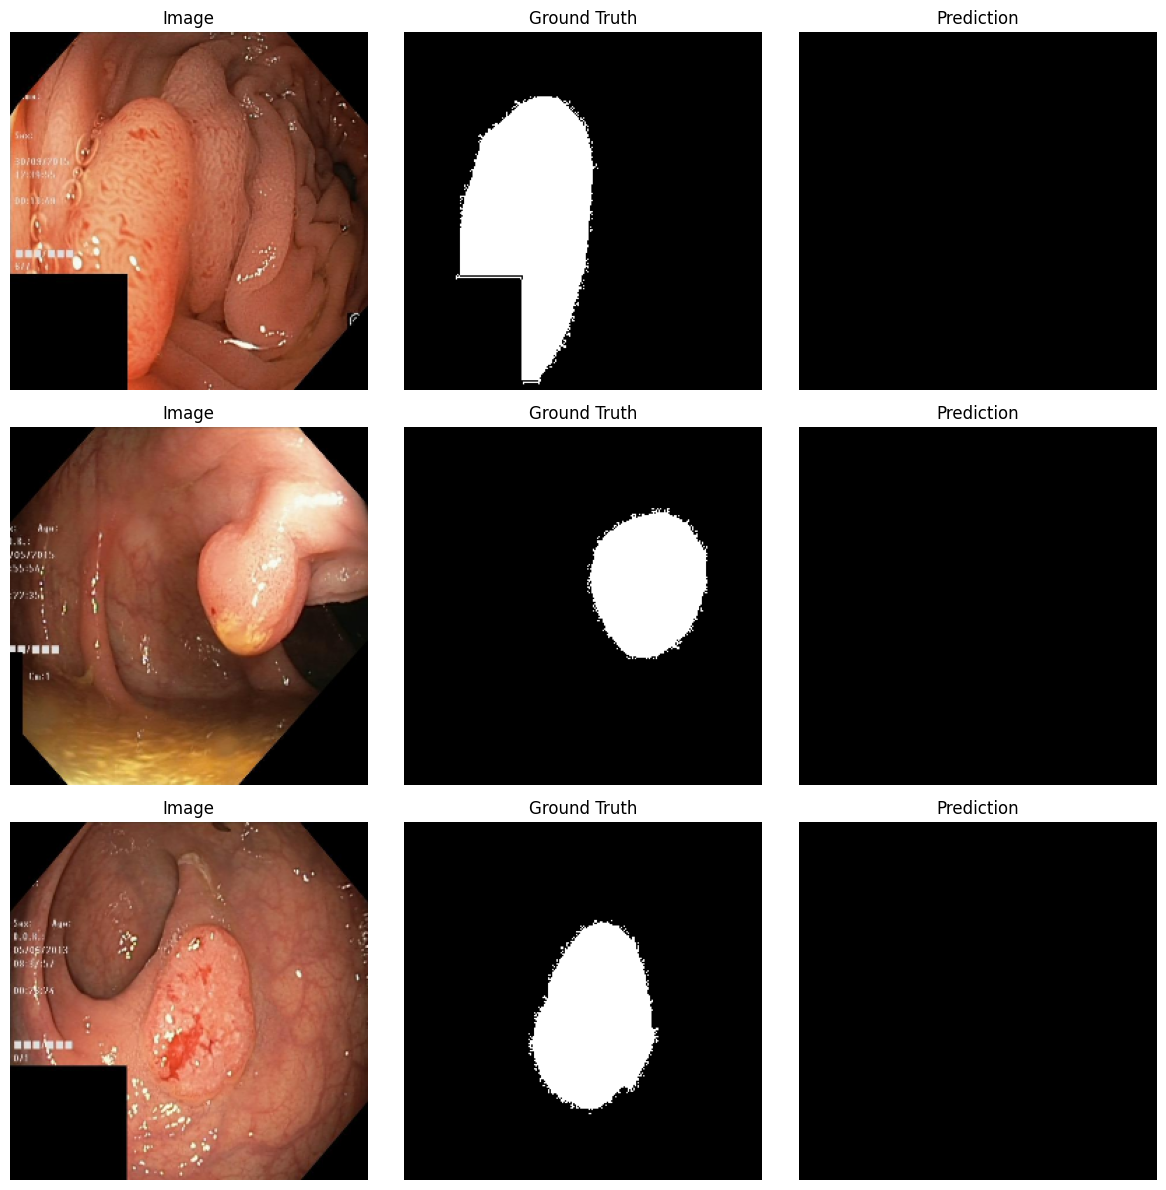

In [ ]:
def visualize_test_predictions(model, dataset, num_samples=3):
    model.eval()
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, num_samples*4))
    indices = random.sample(range(len(dataset)), num_samples)

    for row, idx in enumerate(indices):
        img, mask = dataset[idx]
        img_tensor = img.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(img_tensor)
            pred = (torch.sigmoid(output) > 0.5).squeeze().cpu().numpy().astype(np.uint8)  # <-- FIX: use .squeeze()

        # Denormalize image
        img_np = img.permute(1,2,0).cpu().numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img_np = img_np * std + mean
        img_np = np.clip(img_np, 0, 1)

        mask_np = mask.cpu().numpy()

        axes[row,0].imshow(img_np)
        axes[row,0].set_title('Image')
        axes[row,0].axis('off')

        axes[row,1].imshow(mask_np, cmap='gray')
        axes[row,1].set_title('Ground Truth')
        axes[row,1].axis('off')

        axes[row,2].imshow(pred, cmap='gray')
        axes[row,2].set_title('Prediction')
        axes[row,2].axis('off')

    plt.tight_layout()
    plt.savefig('results/test_predictions.png', dpi=150)
    plt.show()

# Call the function
visualize_test_predictions(model, test_dataset, num_samples=3)